# Vietnamese License Plate YOLO - Scratch Training V62  
## Vehicle License Plate Detection and Recognition Using YOLO and OCR

**Class:** 22DTV_CLC1  
**Group:** Group 5

**Team Members:**

- Mai Xuan Khang
- Luong Hai Long
- Tran Si Nam
- Van Dinh Nam
- Le Tan Phi Pha
- Truong Quang Vu
- Ly Phi Hung

**Final Seminar Project:** Vehicle license plate detection and recognition using the YOLO model and OCR techniques on the Vietnamese License Plates Detection dataset.

**Supervising Lecturers:**

- Dr. Dang Le Khoa
- MSc. Nguyen Thai Cong Nghia
- BSc. Nguyen Dung

**Checkpoint Note:** Ver62 is the first checkpoint. Ver65 is the second checkpoint.

This notebook records the first checkpoint for the final seminar project. The detector is trained from scratch for 25 epochs, then the required evaluation metrics are collected for the report.

## Training Setup

This run starts from a blank YOLO configuration. It does **not** load:

- `last.pt`
- `best.pt`
- `detector_used.pt`
- any earlier checkpoint
- `resume=True`

The training data comes from the prepared Vietnamese license plate dataset folders:

```text
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/train
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/test
```

## Notes for the Report

Cell **8** prints the required values: Precision, Recall, mAP50, and mAP50-95. The final OCR preview cell was removed so the notebook ends cleanly after the comparison note.


In [1]:
# ============================================================
# 1) Environment setup
# ============================================================
import os, sys, re, time, random, shutil, zipfile, subprocess
from pathlib import Path
from datetime import datetime

os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
os.environ["YOLO_CONFIG_DIR"] = "/tmp/Ultralytics"
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

IN_KAGGLE = Path("/kaggle").exists()
WORK_DIR = Path("/kaggle/working") if IN_KAGGLE else Path(".")
print("IN_KAGGLE =", IN_KAGGLE)
print("WORK_DIR  =", WORK_DIR)
print("Python    =", sys.version)

def run_pip_install(packages):
    if isinstance(packages, str):
        packages = [packages]
    cmd = [sys.executable, "-m", "pip", "install", "--no-cache-dir", "--disable-pip-version-check", *packages]
    print("Running:", " ".join(cmd))
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    print("pip return code:", p.returncode)
    if p.stdout: print("----- pip stdout -----\n", p.stdout[-6000:])
    if p.stderr: print("----- pip stderr -----\n", p.stderr[-6000:])
    if p.returncode != 0:
        raise RuntimeError("pip install failed. Enable Kaggle Internet, restart session, then run again.")

try:
    import ultralytics
    print("ultralytics:", ultralytics.__version__)
except Exception as e:
    print("Ultralytics missing:", repr(e))
    run_pip_install(["ultralytics"])
    import ultralytics
    print("ultralytics:", ultralytics.__version__)

import yaml
import pandas as pd
import numpy as np
import cv2
from ultralytics import YOLO

try:
    import torch
    print("torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU count:", torch.cuda.device_count())
        for i in range(torch.cuda.device_count()):
            prop = torch.cuda.get_device_properties(i)
            print(i, torch.cuda.get_device_name(i), round(prop.total_memory / 1024**3, 2), "GB")
except Exception as e:
    print("Torch info error:", repr(e))

IN_KAGGLE = True
WORK_DIR  = /kaggle/working
Python    = 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Ultralytics missing: ModuleNotFoundError("No module named 'ultralytics'")
Running: /usr/bin/python3 -m pip install --no-cache-dir --disable-pip-version-check ultralytics
pip return code: 0
----- pip stdout -----
 ne-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 112.9 MB/s eta 0:00:00

WARNING ⚠️ user config directory '/tmp/Ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.45
torch: 2.10.0+cu128
CUDA available: True
GPU count: 2
0 Tesla T4 14.56 GB
1 Tesla T4 14.56 GB


In [2]:
# ============================================================
# 2) Scratch configuration
# ============================================================
# This is a blank/scratch run:
# - no checkpoint path
# - no resume=True
# - no YOLO("*.pt")
# - only YOLO("*.yaml")
# ============================================================

VERSION = "V60_SCRATCH_25E"

INPUT_ROOT = Path("/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint")
DATASET_ROOT = INPUT_ROOT / "v58_merged_dataset_real"

# Scratch architecture. If yolov9s.yaml is unavailable in your Ultralytics build,
# the notebook will automatically fall back to yolov8n.yaml.
MODEL_YAML = "yolov9s.yaml"

EPOCHS = 25
IMG_SIZE = 768
BATCH = 16
WORKERS = 2
AMP = True
DEVICE = "auto"

# Scratch training LR. Reduce LR0 to 0.003 if losses become unstable.
LR0 = 0.006
LRF = 0.01
WARMUP_EPOCHS = 3.0
PATIENCE = 8

MOSAIC = 0.60
CLOSE_MOSAIC = 5
COS_LR = True
SEED = 22
SAVE_PERIOD = 1

PROJECT = WORK_DIR / "runs_vnlp_public_v62_scratch25"
RUN_NAME = "v60_scratch25_no_checkpoint"
ZIP_NAME = "vnlp_public_v62_scratch25_percent_demo_checkpoint.zip"
DATA_YAML = WORK_DIR / "v62_scratch_dataset.yaml"

RUN_YOLO_PREVIEW = True
PREVIEW_CONF = 0.15
PREVIEW_MAX_IMAGES = 32
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("VERSION        =", VERSION)
print("DATASET_ROOT   =", DATASET_ROOT)
print("MODEL_YAML     =", MODEL_YAML)
print("EPOCHS         =", EPOCHS)
print("CHECKPOINT     = None; training from scratch")

VERSION        = V60_SCRATCH_25E
DATASET_ROOT   = /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real
MODEL_YAML     = yolov9s.yaml
EPOCHS         = 25
CHECKPOINT     = None; training from scratch


In [3]:
# ============================================================
# 3) Verify dataset and write data.yaml
# ============================================================
def count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_labels(folder: Path) -> int:
    if not folder.exists():
        return 0
    return len(list(folder.rglob("*.txt")))

for p in [
    DATASET_ROOT / "train" / "images",
    DATASET_ROOT / "train" / "labels",
    DATASET_ROOT / "valid" / "images",
    DATASET_ROOT / "valid" / "labels",
    DATASET_ROOT / "test" / "images",
    DATASET_ROOT / "test" / "labels",
]:
    print(p, "exists=", p.exists())

if not (DATASET_ROOT / "train" / "images").exists():
    raise FileNotFoundError("Missing train/images")
if not (DATASET_ROOT / "valid" / "images").exists():
    raise FileNotFoundError("Missing valid/images")

rows = []
for split in ["train", "valid", "test"]:
    rows.append({
        "split": split,
        "images": count_images(DATASET_ROOT / split / "images"),
        "labels": count_labels(DATASET_ROOT / split / "labels"),
        "image_dir": str(DATASET_ROOT / split / "images"),
        "label_dir": str(DATASET_ROOT / split / "labels"),
    })

stats_df = pd.DataFrame(rows)
display(stats_df)

test_images = count_images(DATASET_ROOT / "test" / "images")
data_yaml = {
    "path": str(DATASET_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images" if test_images > 0 else "valid/images",
    "names": {0: "license_plate"},
    "nc": 1,
}
DATA_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True), encoding="utf-8")
print(DATA_YAML.read_text(encoding="utf-8"))

/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/train/images exists= True
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/train/labels exists= True
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/images exists= True
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/labels exists= True
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/test/images exists= True
/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/test/labels exists= True


,split,images,labels,image_dir,label_dir
0,train,49417,49417,/kaggle/input/datasets/triuthanhhng/vn-plate-l...,/kaggle/input/datasets/triuthanhhng/vn-plate-l...
1,valid,9465,9465,/kaggle/input/datasets/triuthanhhng/vn-plate-l...,/kaggle/input/datasets/triuthanhhng/vn-plate-l...
2,test,3340,3340,/kaggle/input/datasets/triuthanhhng/vn-plate-l...,/kaggle/input/datasets/triuthanhhng/vn-plate-l...


path: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real
train: train/images
val: valid/images
test: test/images
names:
  0: license_plate
nc: 1



In [4]:
# ============================================================
# 4) Label sanity check
# ============================================================
# YOLO detect labels must have exactly 5 columns:
# class x_center y_center width height
# ============================================================

def check_label_files(label_root: Path, max_bad_print=20):
    bad_files, total_files, total_boxes = [], 0, 0
    for txt_path in label_root.rglob("*.txt"):
        total_files += 1
        text = txt_path.read_text(encoding="utf-8", errors="ignore")
        if "\\n" in text:
            bad_files.append(txt_path)
            if len(bad_files) <= max_bad_print:
                print("BAD literal backslash-n:", txt_path)
            continue
        for line in text.splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) != 5:
                bad_files.append(txt_path)
                if len(bad_files) <= max_bad_print:
                    print("BAD column count:", txt_path, "line=", repr(line))
                break
            try:
                _ = float(parts[0])
                vals = [float(x) for x in parts[1:]]
                if not all(np.isfinite(vals)):
                    raise ValueError("non-finite")
                total_boxes += 1
            except Exception:
                bad_files.append(txt_path)
                if len(bad_files) <= max_bad_print:
                    print("BAD float parse:", txt_path, "line=", repr(line))
                break
    print("Checked label files:", total_files)
    print("Checked boxes:", total_boxes)
    print("Bad label files:", len(bad_files))
    if bad_files:
        raise RuntimeError("Invalid YOLO label formatting found.")

for split in ["train", "valid", "test"]:
    label_dir = DATASET_ROOT / split / "labels"
    if label_dir.exists():
        print(f"Checking {split} labels:", label_dir)
        check_label_files(label_dir)

Checking train labels: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/train/labels
Checked label files: 49417
Checked boxes: 67940
Bad label files: 0
Checking valid labels: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/labels
Checked label files: 9465
Checked boxes: 13718
Bad label files: 0
Checking test labels: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/test/labels
Checked label files: 3340
Checked boxes: 5185
Bad label files: 0


In [5]:
# ============================================================
# 5) Device selection
# ============================================================
def pick_device(device_setting):
    if str(device_setting).lower() != "auto":
        return device_setting
    try:
        import torch
        if not torch.cuda.is_available():
            return "cpu"
        if torch.cuda.device_count() >= 2:
            return "0,1"
        return 0
    except Exception:
        return "cpu"

TRAIN_DEVICE = pick_device(DEVICE)
print("TRAIN_DEVICE =", TRAIN_DEVICE)

TRAIN_DEVICE = 0,1


In [6]:
# ============================================================
# 6) Build scratch model
# ============================================================
# Critical scratch rule:
# YOLO(MODEL_YAML), not YOLO('*.pt').
# ============================================================

print("Building model from scratch:", MODEL_YAML)
try:
    model = YOLO(MODEL_YAML)
except Exception as e:
    print("Cannot load", MODEL_YAML, "error:", repr(e))
    print("Fallback to yolov8n.yaml for a guaranteed scratch baseline.")
    MODEL_YAML = "yolov8n.yaml"
    model = YOLO(MODEL_YAML)

print("Scratch architecture used:", MODEL_YAML)

Building model from scratch: yolov9s.yaml
Scratch architecture used: yolov9s.yaml


In [7]:
# ============================================================
# 7) Train from scratch for 25 epochs
# ============================================================
start_time = time.time()

train_result = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    workers=WORKERS,
    device=TRAIN_DEVICE,
    amp=AMP,

    project=str(PROJECT),
    name=RUN_NAME,
    exist_ok=True,
    save=True,
    save_period=SAVE_PERIOD,
    plots=True,

    optimizer="auto",
    lr0=LR0,
    lrf=LRF,
    warmup_epochs=WARMUP_EPOCHS,
    patience=PATIENCE,
    cos_lr=COS_LR,
    mosaic=MOSAIC,
    close_mosaic=CLOSE_MOSAIC,
    seed=SEED,
    cache=False,
)

RUN_DIR = PROJECT / RUN_NAME
elapsed_hours = (time.time() - start_time) / 3600

print("Scratch training finished.")
print("Elapsed hours:", round(elapsed_hours, 3))
print("RUN_DIR:", RUN_DIR)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/v62_scratch_dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.006, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.yaml, momentum=0.937, mosaic=0.6, multi_scale=0.0, name=v60_scrat

In [8]:
# ============================================================
# 8) REQUIRED METRICS CELL
# Precision, Recall, mAP50, mAP50-95
# ============================================================

RUN_DIR = PROJECT / RUN_NAME
best_pt = RUN_DIR / "weights" / "best.pt"
last_pt = RUN_DIR / "weights" / "last.pt"
results_csv = RUN_DIR / "results.csv"

print("best.pt:", best_pt, "| exists:", best_pt.exists())
print("last.pt:", last_pt, "| exists:", last_pt.exists())
print("results.csv:", results_csv, "| exists:", results_csv.exists())

if not results_csv.exists():
    raise FileNotFoundError(f"Missing results.csv: {results_csv}")

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
display(df.tail(10))

metric_cols = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP50": "metrics/mAP50(B)",
    "mAP50-95": "metrics/mAP50-95(B)",
}

last_row = df.iloc[-1]
last_metrics = {"Selection": "Last epoch", "Epoch": int(last_row["epoch"]) if "epoch" in df.columns else len(df)-1}
for name, col in metric_cols.items():
    last_metrics[name] = float(last_row[col]) if col in df.columns else np.nan

best_idx = df["metrics/mAP50-95(B)"].idxmax() if "metrics/mAP50-95(B)" in df.columns else df.index[-1]
best_row = df.loc[best_idx]
best_metrics = {"Selection": "Best by mAP50-95", "Epoch": int(best_row["epoch"]) if "epoch" in df.columns else int(best_idx)}
for name, col in metric_cols.items():
    best_metrics[name] = float(best_row[col]) if col in df.columns else np.nan

metrics_table = pd.DataFrame([last_metrics, best_metrics])
display(metrics_table)

print("\nLast epoch metrics:")
print("Precision :", last_metrics["Precision"])
print("Recall    :", last_metrics["Recall"])
print("mAP50     :", last_metrics["mAP50"])
print("mAP50-95  :", last_metrics["mAP50-95"])

print("\nBest epoch by mAP50-95:")
print("Epoch     :", best_metrics["Epoch"])
print("Precision :", best_metrics["Precision"])
print("Recall    :", best_metrics["Recall"])
print("mAP50     :", best_metrics["mAP50"])
print("mAP50-95  :", best_metrics["mAP50-95"])

metrics_out = WORK_DIR / "v62_scratch25_metrics_summary.csv"
metrics_table.to_csv(metrics_out, index=False, encoding="utf-8-sig")
print("Saved metrics summary:", metrics_out)

best.pt: /kaggle/working/runs_vnlp_public_v62_scratch25/v60_scratch25_no_checkpoint/weights/best.pt | exists: True
last.pt: /kaggle/working/runs_vnlp_public_v62_scratch25/v60_scratch25_no_checkpoint/weights/last.pt | exists: True
results.csv: /kaggle/working/runs_vnlp_public_v62_scratch25/v60_scratch25_no_checkpoint/results.csv | exists: True


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
15,16,24126.2,0.92479,0.37839,1.28885,0.99391,0.99096,0.99434,0.75731,0.91040,0.30379,1.19969,0.010561,0.003520,0.010561,0.003520,0.010561,0.003520,0.010561,0.003520
16,17,25589.1,0.91200,0.36849,1.27771,0.99444,0.99071,0.99437,0.75826,0.90886,0.30200,1.19760,0.008827,0.002942,0.008827,0.002942,0.008827,0.002942,0.008827,0.002942
17,18,27054.4,0.89663,0.35943,1.26888,0.99489,0.99067,0.99436,0.76054,0.90659,0.30053,1.19695,0.007193,0.002398,0.007193,0.002398,0.007193,0.002398,0.007193,0.002398
18,19,28527.9,0.88700,0.35058,1.26026,0.99428,0.99118,0.99432,0.76130,0.90419,0.29881,1.19696,0.005684,0.001895,0.005684,0.001895,0.005684,0.001895,0.005684,0.001895
19,20,29995.8,0.88029,0.34568,1.25403,0.99382,0.99125,0.99432,0.76184,0.90253,0.29683,1.19596,0.004325,0.001442,0.004325,0.001442,0.004325,0.001442,0.004325,0.001442
20,21,31454.1,0.84580,0.30054,1.23518,0.99402,0.99154,0.99438,0.76315,0.90061,0.29546,1.19498,0.003136,0.001045,0.003136,0.001045,0.003136,0.001045,0.003136,0.001045
21,22,32909.6,0.83562,0.29488,1.22270,0.99413,0.99176,0.99438,0.76423,0.89894,0.29482,1.19348,0.002137,0.000712,0.002137,0.000712,0.002137,0.000712,0.002137,0.000712
22,23,34365.1,0.82537,0.28796,1.21799,0.99334,0.99256,0.99438,0.76449,0.89758,0.29343,1.19272,0.001343,0.000448,0.001343,0.000448,0.001343,0.000448,0.001343,0.000448
23,24,35822.6,0.81704,0.28497,1.21203,0.99329,0.99259,0.99434,0.76457,0.89650,0.29278,1.19199,0.000767,0.000256,0.000767,0.000256,0.000767,0.000256,0.000767,0.000256
24,25,37281.0,0.81345,0.28201,1.20769,0.99332,0.99271,0.99439,0.76497,0.89553,0.29206,1.19126,0.000417,0.000139,0.000417,0.000139,0.000417,0.000139,0.000417,0.000139


,Selection,Epoch,Precision,Recall,mAP50,mAP50-95
0,Last epoch,25,0.99332,0.99271,0.99439,0.76497
1,Best by mAP50-95,25,0.99332,0.99271,0.99439,0.76497



Last epoch metrics:
Precision : 0.99332
Recall    : 0.99271
mAP50     : 0.99439
mAP50-95  : 0.76497

Best epoch by mAP50-95:
Epoch     : 25
Precision : 0.99332
Recall    : 0.99271
mAP50     : 0.99439
mAP50-95  : 0.76497
Saved metrics summary: /kaggle/working/v62_scratch25_metrics_summary.csv


In [9]:
# ============================================================
# 9) Validate best.pt
# ============================================================

if best_pt.exists():
    print("Validating scratch best.pt...")
    scratch_model = YOLO(str(best_pt))
    val_metrics = scratch_model.val(
        data=str(DATA_YAML),
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=TRAIN_DEVICE,
    )
    print(val_metrics)
else:
    print("Validation skipped: best.pt missing.")

Validating scratch best.pt...
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLOv9s summary (fused): 197 layers, 7,167,475 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.2±8.8 MB/s, size: 29.3 KB)
val: Scanning /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/labels... 9463 images, 0 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 9465/9465 539.2it/s 17.6s
val: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/images/baocaovan_number_plate_vietnamese_0000358_15.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v58_merged_dataset_real/valid/images/baocaovan_number_plate_vietnamese_0000358_15.jpg'
val: /kaggle/input/datasets/triuthanhhng/vn-plate-lastpt-checkpoint/v5

Preview sample count: 32

0: 768x768 1 license_plate, 15.3ms
1: 768x768 1 license_plate, 15.3ms
2: 768x768 1 license_plate, 15.3ms
3: 768x768 1 license_plate, 15.3ms
4: 768x768 1 license_plate, 15.3ms
5: 768x768 1 license_plate, 15.3ms
6: 768x768 1 license_plate, 15.3ms
7: 768x768 9 license_plates, 15.3ms
8: 768x768 1 license_plate, 15.3ms
9: 768x768 1 license_plate, 15.3ms
10: 768x768 1 license_plate, 15.3ms
11: 768x768 1 license_plate, 15.3ms
12: 768x768 1 license_plate, 15.3ms
13: 768x768 1 license_plate, 15.3ms
14: 768x768 2 license_plates, 15.3ms
15: 768x768 1 license_plate, 15.3ms
16: 768x768 1 license_plate, 15.3ms
17: 768x768 2 license_plates, 15.3ms
18: 768x768 1 license_plate, 15.3ms
19: 768x768 1 license_plate, 15.3ms
20: 768x768 1 license_plate, 15.3ms
21: 768x768 1 license_plate, 15.3ms
22: 768x768 1 license_plate, 15.3ms
23: 768x768 1 license_plate, 15.3ms
24: 768x768 1 license_plate, 15.3ms
25: 768x768 1 license_plate, 15.3ms
26: 768x768 1 license_plate, 15.3ms
27: 768x7

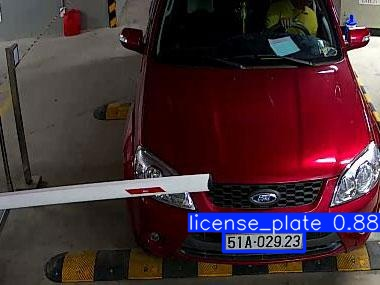

/kaggle/working/v62_scratch25_yolo_preview/image12.jpg


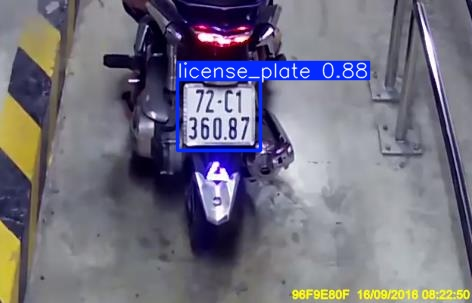

/kaggle/working/v62_scratch25_yolo_preview/image0.jpg


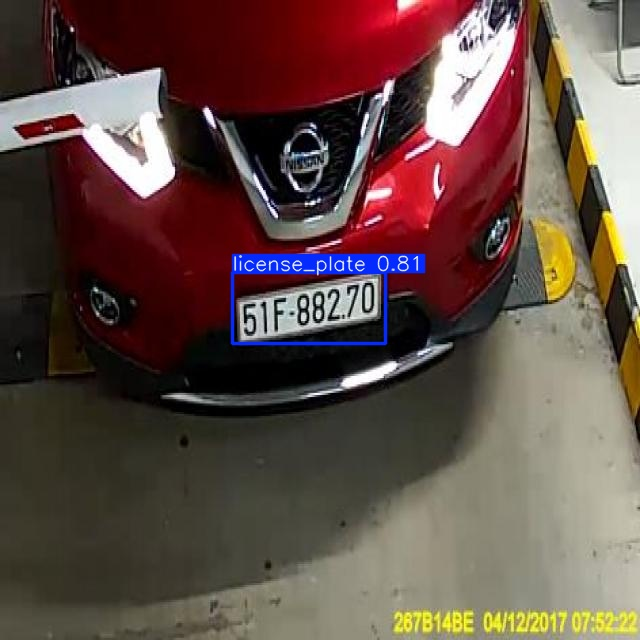

/kaggle/working/v62_scratch25_yolo_preview/image30.jpg


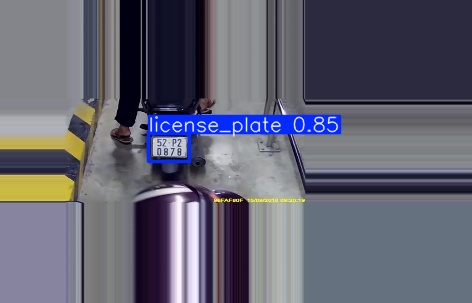

/kaggle/working/v62_scratch25_yolo_preview/image10.jpg


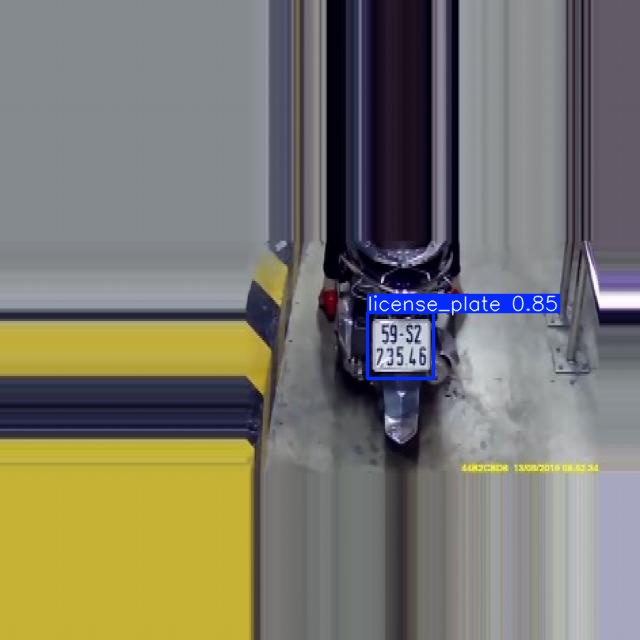

/kaggle/working/v62_scratch25_yolo_preview/image18.jpg


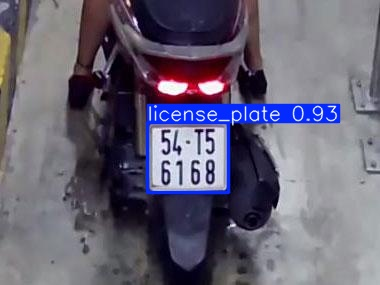

/kaggle/working/v62_scratch25_yolo_preview/image1.jpg


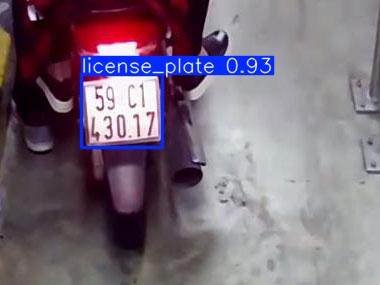

/kaggle/working/v62_scratch25_yolo_preview/image4.jpg


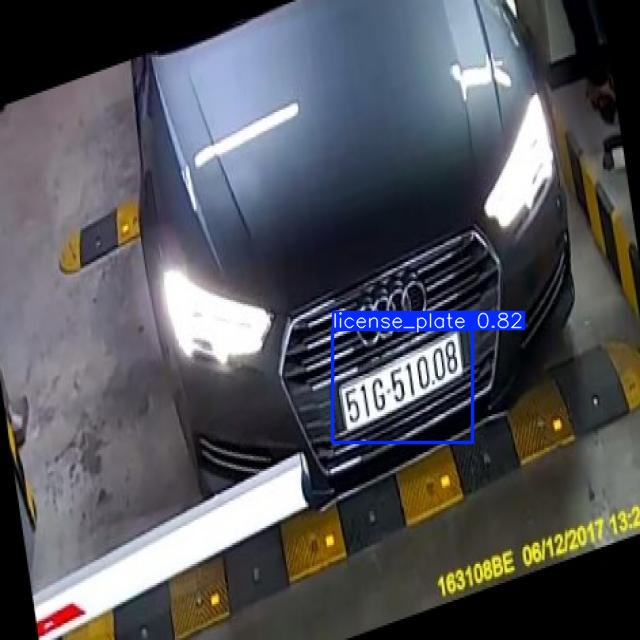

/kaggle/working/v62_scratch25_yolo_preview/image16.jpg


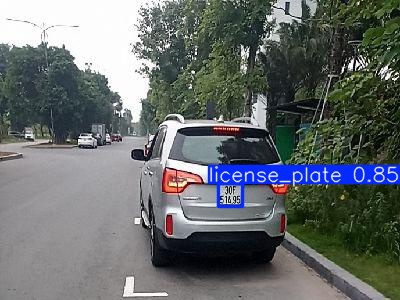

/kaggle/working/v62_scratch25_yolo_preview/image31.jpg


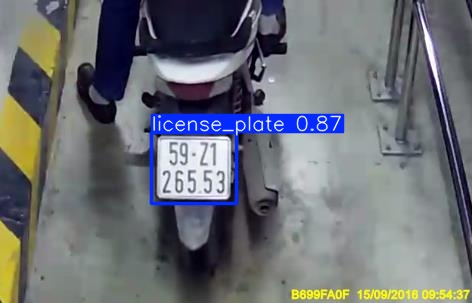

/kaggle/working/v62_scratch25_yolo_preview/image20.jpg


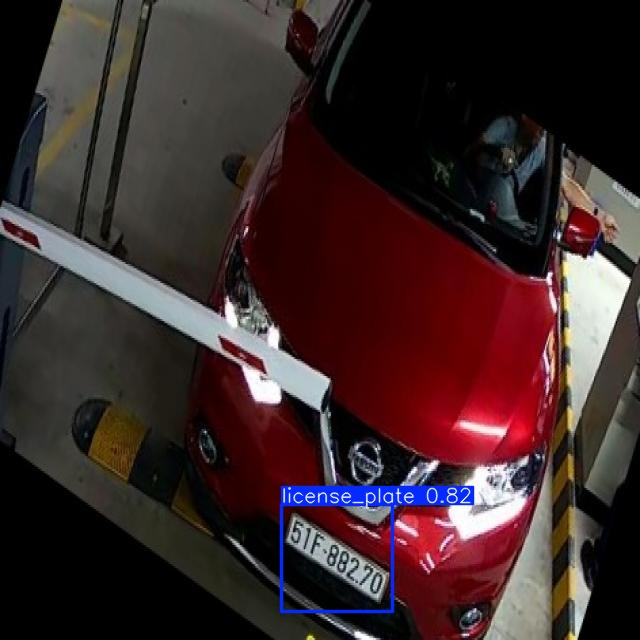

/kaggle/working/v62_scratch25_yolo_preview/image7.jpg


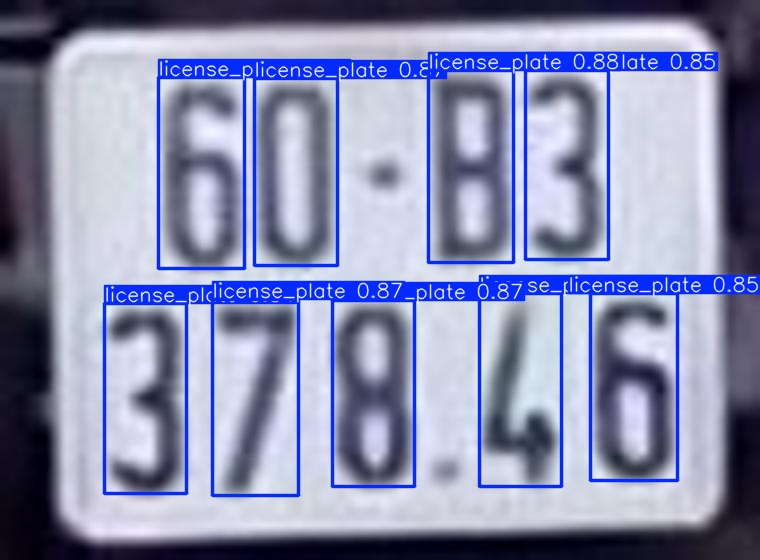

/kaggle/working/v62_scratch25_yolo_preview/image3.jpg


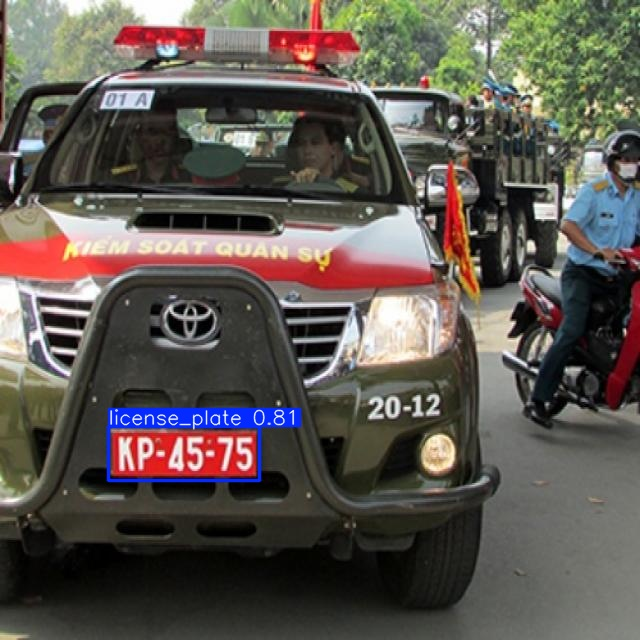

/kaggle/working/v62_scratch25_yolo_preview/image5.jpg


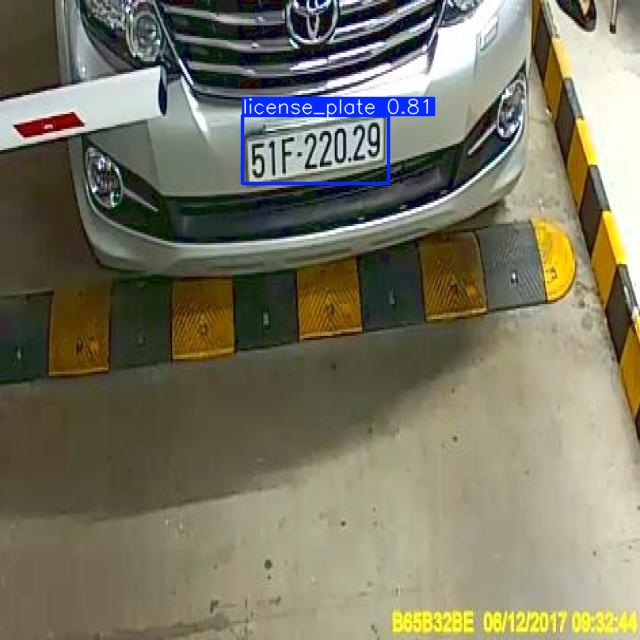

/kaggle/working/v62_scratch25_yolo_preview/image28.jpg


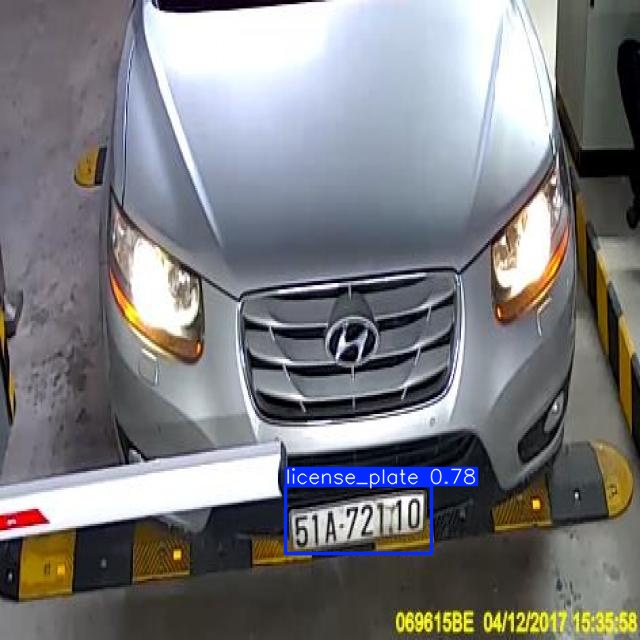

/kaggle/working/v62_scratch25_yolo_preview/image17.jpg


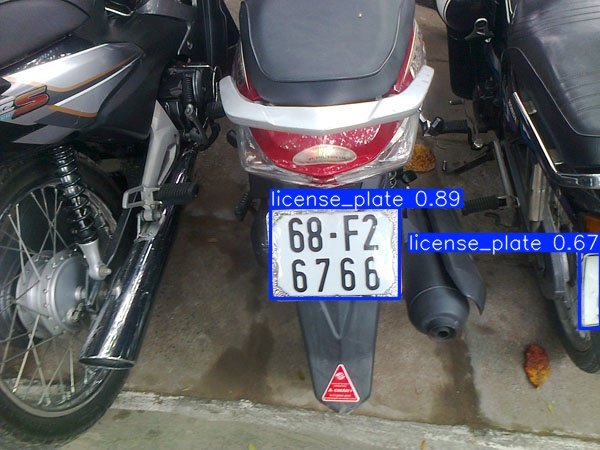

/kaggle/working/v62_scratch25_yolo_preview/image8.jpg


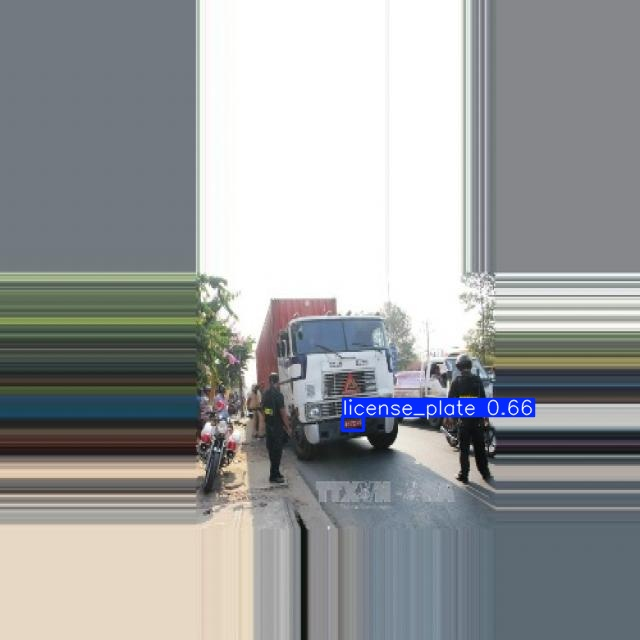

/kaggle/working/v62_scratch25_yolo_preview/image14.jpg


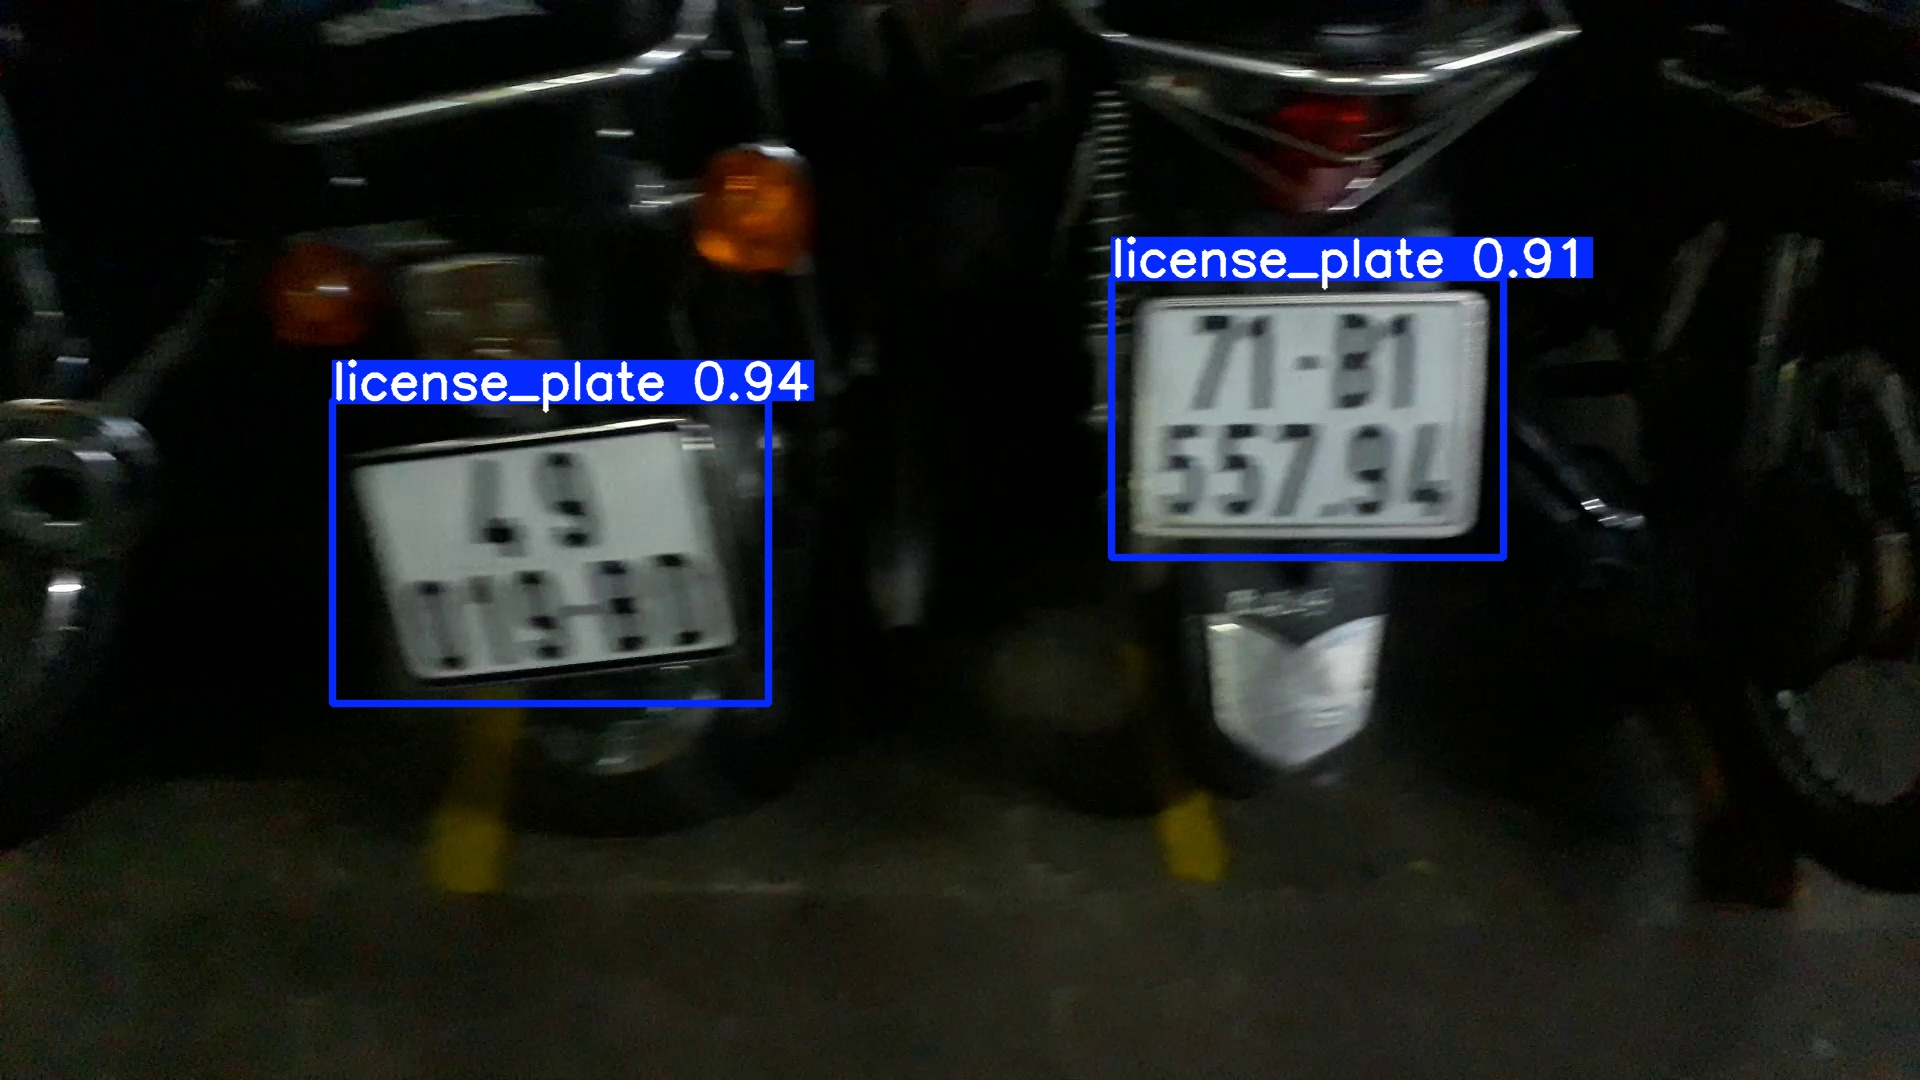

/kaggle/working/v62_scratch25_yolo_preview/image19.jpg


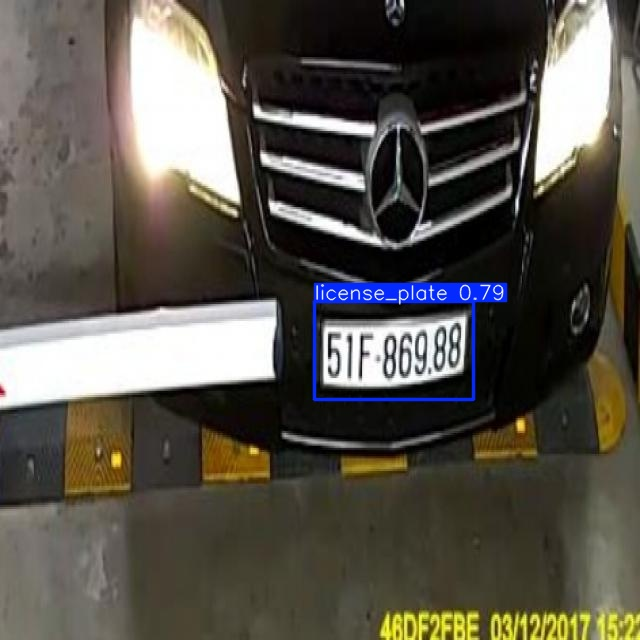

/kaggle/working/v62_scratch25_yolo_preview/image9.jpg


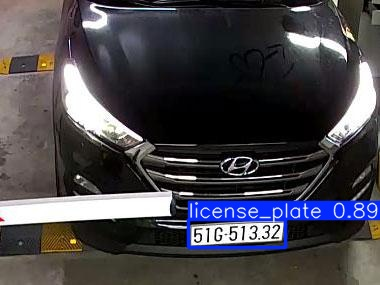

/kaggle/working/v62_scratch25_yolo_preview/image27.jpg


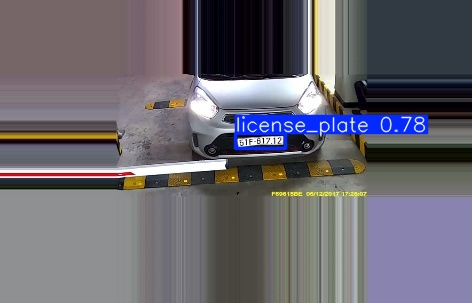

/kaggle/working/v62_scratch25_yolo_preview/image21.jpg


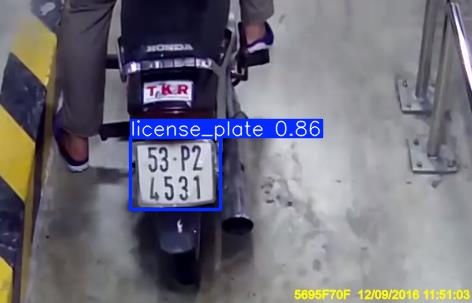

/kaggle/working/v62_scratch25_yolo_preview/image22.jpg


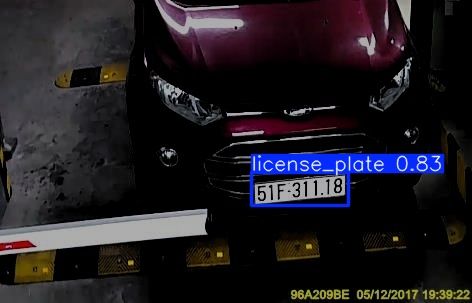

/kaggle/working/v62_scratch25_yolo_preview/image29.jpg


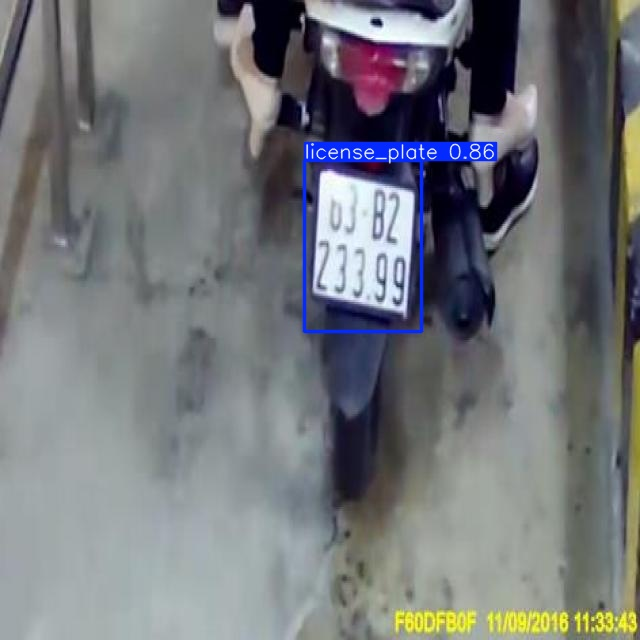

/kaggle/working/v62_scratch25_yolo_preview/image11.jpg


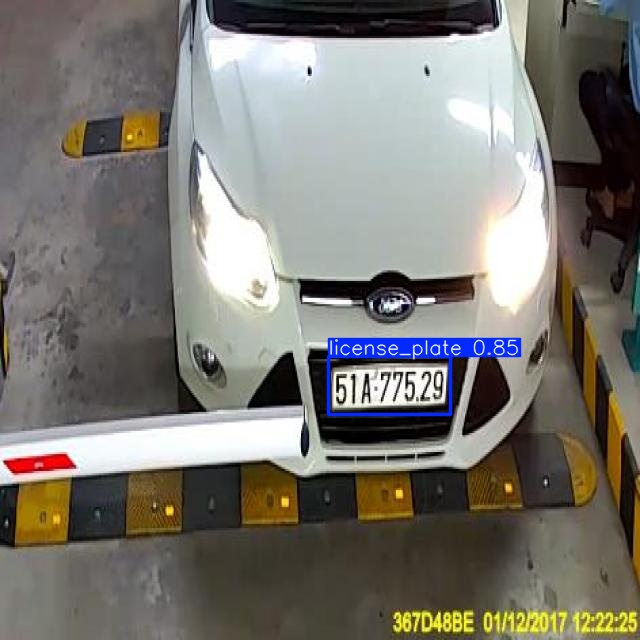

/kaggle/working/v62_scratch25_yolo_preview/image13.jpg


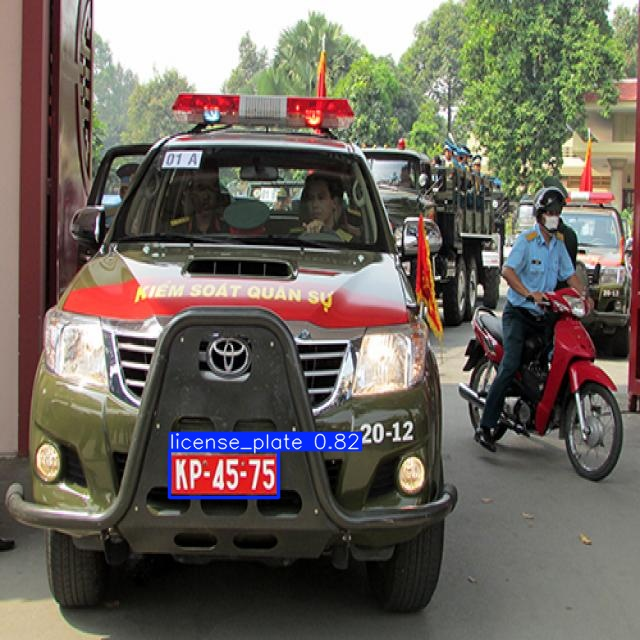

/kaggle/working/v62_scratch25_yolo_preview/image25.jpg


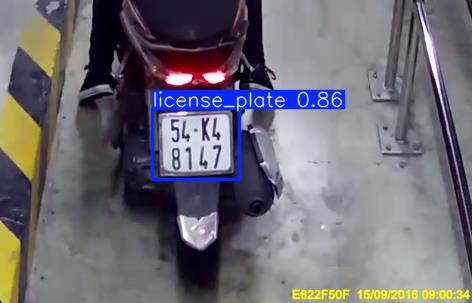

/kaggle/working/v62_scratch25_yolo_preview/image26.jpg


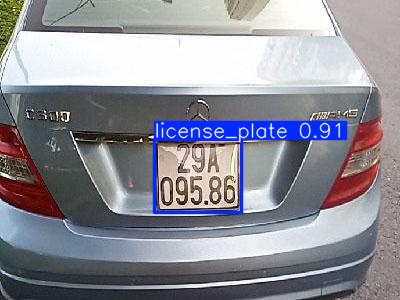

/kaggle/working/v62_scratch25_yolo_preview/image23.jpg


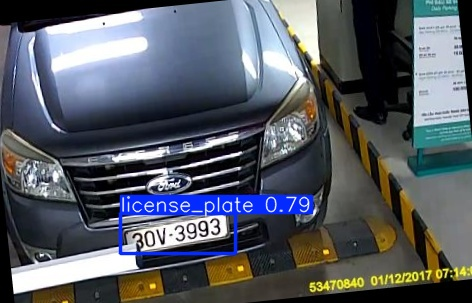

/kaggle/working/v62_scratch25_yolo_preview/image6.jpg


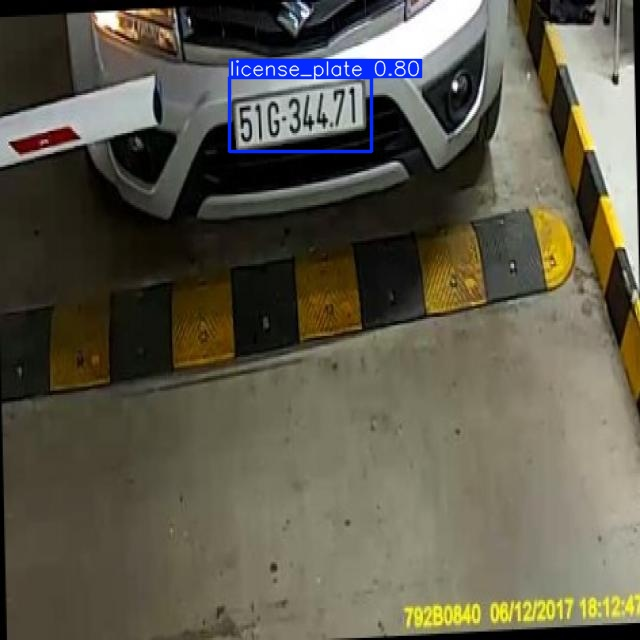

/kaggle/working/v62_scratch25_yolo_preview/image24.jpg


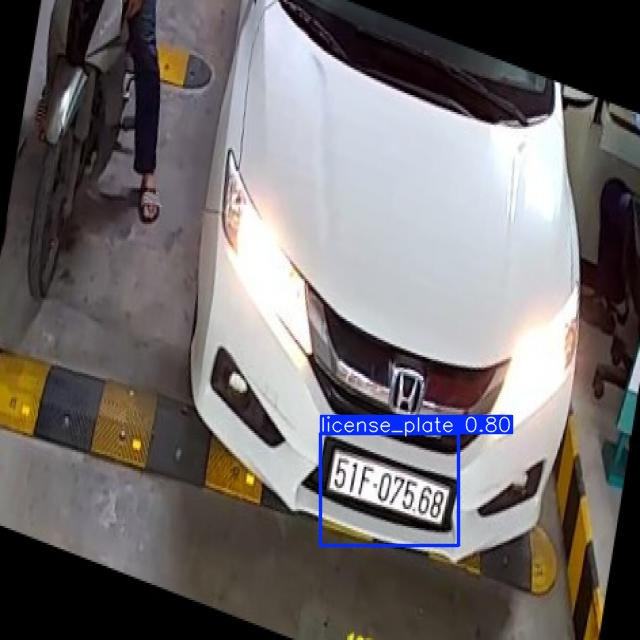

/kaggle/working/v62_scratch25_yolo_preview/image2.jpg


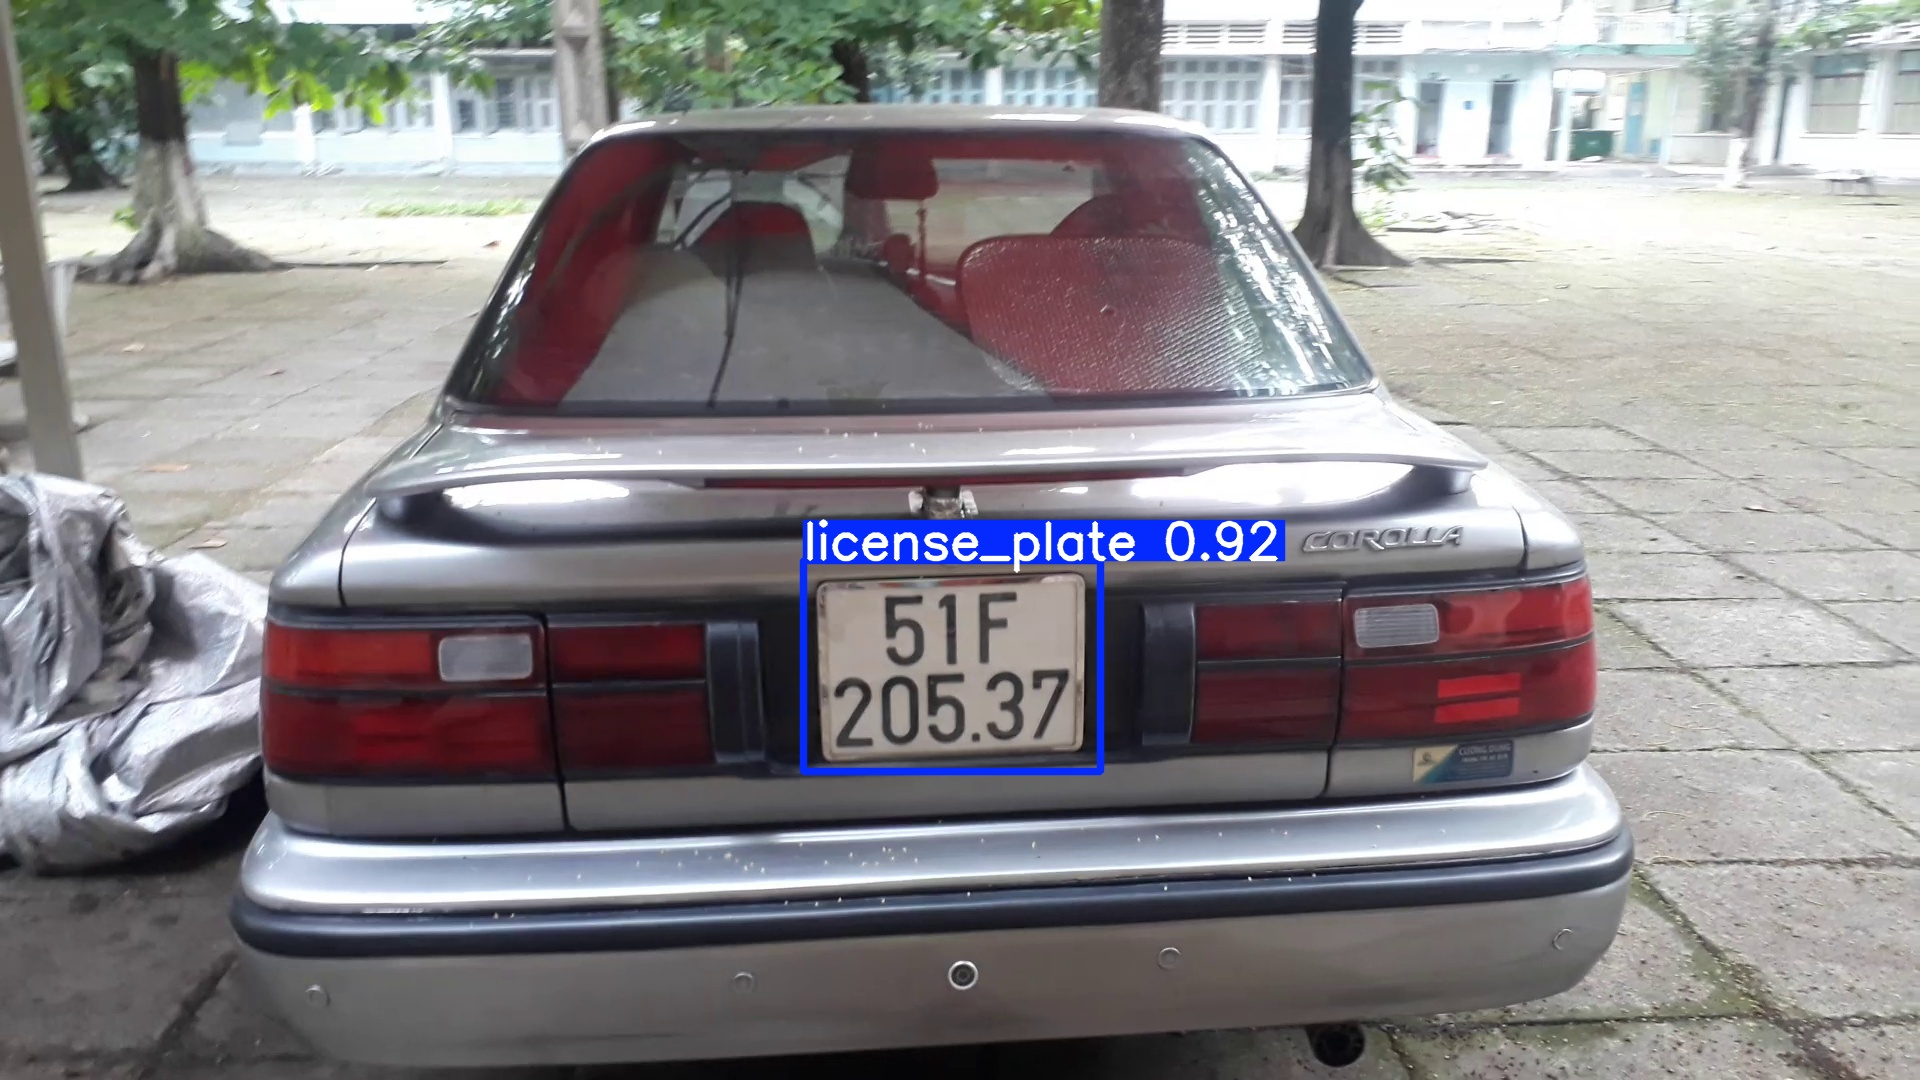

In [10]:
# ============================================================
# 10) YOLO preview
# ============================================================

def sample_images_from_yaml(data_yaml_path, max_images=32):
    cfg = yaml.safe_load(Path(data_yaml_path).read_text(encoding="utf-8"))
    base = Path(cfg.get("path", Path(data_yaml_path).parent))
    roots = []
    for key in ["val", "test", "train"]:
        if key in cfg:
            root = Path(cfg[key])
            if not root.is_absolute():
                root = base / root
            if root.exists():
                roots.append(root)
    images = []
    for root in roots:
        for ext in IMG_EXTS:
            images.extend(root.rglob("*" + ext))
            images.extend(root.rglob("*" + ext.upper()))
        if len(images) >= max_images:
            break
    random.seed(SEED)
    random.shuffle(images)
    return images[:max_images]

if RUN_YOLO_PREVIEW and best_pt.exists():
    from IPython.display import display, Image as IPyImage
    preview_dir = WORK_DIR / "v62_scratch25_yolo_preview"
    detector = YOLO(str(best_pt))
    sample_paths = sample_images_from_yaml(DATA_YAML, PREVIEW_MAX_IMAGES)
    print("Preview sample count:", len(sample_paths))
    if sample_paths:
        detector.predict(
            source=[str(p) for p in sample_paths],
            imgsz=IMG_SIZE,
            conf=PREVIEW_CONF,
            iou=0.55,
            save=True,
            project=str(preview_dir.parent),
            name=preview_dir.name,
            exist_ok=True,
            device=TRAIN_DEVICE,
        )
        for img in list(preview_dir.glob("*"))[:PREVIEW_MAX_IMAGES]:
            if img.suffix.lower() in IMG_EXTS:
                print(img)
                display(IPyImage(filename=str(img), width=850))
else:
    print("Preview skipped.")

In [11]:
# ============================================================
# 11) Create output ZIP
# ============================================================

detector_used = WORK_DIR / "detector_used_scratch25.pt"
if best_pt.exists():
    shutil.copy2(best_pt, detector_used)
    print("Copied:", detector_used)

readme = WORK_DIR / "V62_SCRATCH25_README.txt"
readme.write_text(
    f'''
V62 Scratch 25-epoch YOLO run

This run is trained from scratch.

No previous checkpoint was used:
- no last.pt
- no best.pt
- no detector_used.pt
- no resume=True

Architecture YAML:
{MODEL_YAML}

Dataset:
{DATASET_ROOT}

Run directory:
{RUN_DIR}

Use for app/demo:
{best_pt}

Metrics summary:
{WORK_DIR / "v62_scratch25_metrics_summary.csv"}
'''.strip(),
    encoding="utf-8",
)

def add_if_exists(zf, path, arcname=None):
    path = Path(path)
    if path.exists():
        zf.write(path, arcname=arcname or path.name)

zip_path = WORK_DIR / ZIP_NAME
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for rel in [
        "weights/best.pt", "weights/last.pt", "weights/epoch24.pt",
        "args.yaml", "results.csv", "results.png",
        "confusion_matrix.png", "confusion_matrix_normalized.png",
        "PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png",
        "labels.jpg", "labels_correlogram.jpg",
    ]:
        p = RUN_DIR / rel
        if p.exists():
            zf.write(p, arcname=str(Path("scratch_run") / rel))
    add_if_exists(zf, detector_used, "detector_used_scratch25.pt")
    add_if_exists(zf, DATA_YAML, "v62_scratch_dataset.yaml")
    add_if_exists(zf, WORK_DIR / "v62_scratch25_metrics_summary.csv", "v62_scratch25_metrics_summary.csv")
    add_if_exists(zf, readme, "V62_SCRATCH25_README.txt")
    preview_dir = WORK_DIR / "v62_scratch25_yolo_preview"
    if preview_dir.exists():
        for p in preview_dir.rglob("*"):
            if p.is_file():
                zf.write(p, arcname=str(Path("v62_scratch25_yolo_preview") / p.relative_to(preview_dir)))

print("Created zip:", zip_path)
print("Zip size MB:", round(zip_path.stat().st_size / 1024**2, 2))

Copied: /kaggle/working/detector_used_scratch25.pt
Created zip: /kaggle/working/vnlp_public_v62_scratch25_percent_demo_checkpoint.zip
Zip size MB: 81.03


In [12]:
# ============================================================
# 12) Download links
# ============================================================

try:
    from IPython.display import FileLink, display
    for path, title in [
        (best_pt, "best.pt — scratch best checkpoint"),
        (last_pt, "last.pt — scratch last checkpoint"),
        (detector_used, "detector_used_scratch25.pt"),
        (WORK_DIR / "v62_scratch25_metrics_summary.csv", "metrics summary CSV"),
        (zip_path, "scratch checkpoint ZIP"),
    ]:
        path = Path(path)
        if path.exists():
            print(title)
            display(FileLink(str(path)))
except Exception as e:
    print("FileLink error:", repr(e))

best.pt — scratch best checkpoint


/kaggle/working/runs_vnlp_public_v62_scratch25/v60_scratch25_no_checkpoint/weights/best.pt

last.pt — scratch last checkpoint


/kaggle/working/runs_vnlp_public_v62_scratch25/v60_scratch25_no_checkpoint/weights/last.pt

detector_used_scratch25.pt


/kaggle/working/detector_used_scratch25.pt

metrics summary CSV


/kaggle/working/v62_scratch25_metrics_summary.csv

scratch checkpoint ZIP


/kaggle/working/vnlp_public_v62_scratch25_percent_demo_checkpoint.zip

## Report Comparison Note

Use Ver62 as the first checkpoint result in the final report. It is the scratch-training baseline before the continuation run in Ver65.

| Run type | Precision | Recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| First checkpoint - Ver62 scratch run | use Ver62 result | use Ver62 result | use Ver62 result | use Ver62 result |
| Second checkpoint - Ver65 continuation run | use Ver65 result | use Ver65 result | use Ver65 result | use Ver65 result |

The required metrics are printed in cell **8**.
